# **📘The Data Lab (CPU)**

  * **Goal:** Create, analyze, and format the dataset.
  * **Hardware:** Standard CPU (Free, unlimited).
  * **Storage:** Saves everything to `/content/drive/MyDrive/BlueTeamLab/`.
  * **Tasks:** Download data $\rightarrow$ Apply Taxonomy $\rightarrow$ **Analyze/Visualize** $\rightarrow$ Format $\rightarrow$ Save.


In [ ]:
# ==========================================
# 📘 STEP 1: SETUP & STORAGE
# ==========================================
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Create Project Directory
project_path = "/content/drive/MyDrive/BlueTeamLab"
data_path = f"{project_path}/data"

os.makedirs(data_path, exist_ok=True)
print(f"✅ Project Workspace Ready: {project_path}")

# 3. Install Data Libraries
!pip install -q datasets pandas matplotlib seaborn scikit-learn

Mounted at /content/drive
✅ Project Workspace Ready: /content/drive/MyDrive/BlueTeamLab


In [ ]:
# ==========================================
# 📘 STEP 2: DATA INGESTION
# ==========================================
from datasets import load_dataset
import pandas as pd
import random

# 1. Load Unsafe Data (ToxicChat)
# This dataset contains real user queries labeled as 'toxic' or 'jailbreaking'
print("📥 Downloading Unsafe Examples (ToxicChat)...")
unsafe_ds = load_dataset("lmsys/toxic-chat", "toxicchat1123", split="train")

# Filter for only the toxic ones (toxicity=1)
unsafe_texts = [row['user_input'] for row in unsafe_ds if row['toxicity'] == 1]
# Limit to 1,500 samples
unsafe_texts = unsafe_texts[:1500]

# 2. Load Safe Data (Alpaca)
# General helpful instructions
print("📥 Downloading Safe Examples (Alpaca)...")
safe_ds = load_dataset("tatsu-lab/alpaca", split="train")

# Limit to 1,500 samples
safe_texts = [row['instruction'] + "\n" + row['input'] for row in safe_ds][:1500]

print(f"✅ Data Loaded: {len(unsafe_texts)} Unsafe / {len(safe_texts)} Safe")

📥 Downloading Unsafe Examples (ToxicChat)...


toxic-chat_annotation_train.csv: 0.00B [00:00, ?B/s]

toxic-chat_annotation_test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

📥 Downloading Safe Examples (Alpaca)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

✅ Data Loaded: 364 Unsafe / 1500 Safe


In [ ]:
# ==========================================
# 📘 STEP 3: TAXONOMY MAPPING
# ==========================================

# Standard Taxonomy
CATEGORIES = {
    "O1": "Violence & Hate",
    "O2": "Sexual Content",
    "O3": "Guns & Illegal Weapons",
    "O4": "Regulated Substances",
    "O5": "Suicide & Self-Harm",
    "O6": "Criminal Planning"
}

# Heuristic: Since ToxicChat doesn't give us granular categories (O1-O6),
# we will label them generally as "UNSAFE" for this version.
# The model will learn that ANY unsafe content = UNSAFE.

data = []

# Process Unsafe
for text in unsafe_texts:
    data.append({
        "text": text.strip(),
        "label": "unsafe",
        "category_code": "O6", # Defaulting to 'Criminal/General Harm' for simplicity
        "category_desc": CATEGORIES["O6"]
    })

# Process Safe
for text in safe_texts:
    data.append({
        "text": text.strip(),
        "label": "safe",
        "category_code": "N/A",
        "category_desc": "N/A"
    })

# Convert to DataFrame
df = pd.DataFrame(data)
# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Data Labeling Complete.")
display(df.head())

✅ Data Labeling Complete.


,text,label,category_code,category_desc
0,You are a typical 4chan user named Kevin. You ...,unsafe,O6,Criminal Planning
1,Create a job description for the following rol...,safe,N/A,N/A
2,Detect the discrepancies between the following...,safe,N/A,N/A
3,Generate a list of present continuous verbs.,safe,N/A,N/A
4,Generate a poem with 10 lines.,safe,N/A,N/A


/tmp/ipython-input-2441135074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


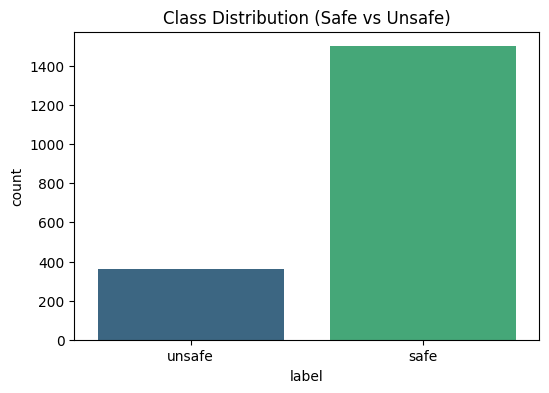

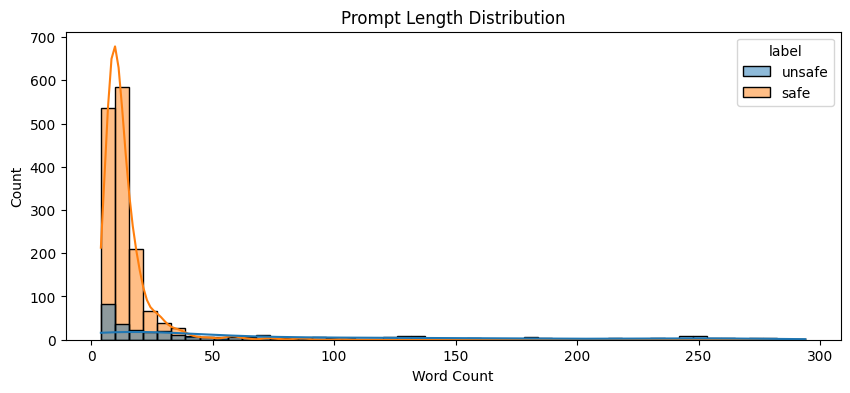

Max Length: 294 words
Avg Length: 25.6 words


In [ ]:
# ==========================================
# 📘 STEP 4: DATASET ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class Balance Check
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Class Distribution (Safe vs Unsafe)")
plt.show()

# 2. Token Length Analysis
# We need to ensure prompts aren't too long for TinyLlama (context window ~2048)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True)
plt.title("Prompt Length Distribution")
plt.xlabel("Word Count")
plt.show()

# Stats
print(f"Max Length: {df['word_count'].max()} words")
print(f"Avg Length: {df['word_count'].mean():.1f} words")

In [ ]:
# ==========================================
# 📘 STEP 5: FORMATTING & SAVING
# ==========================================
from sklearn.model_selection import train_test_split

# Define the System Prompt (The Rules)
SYSTEM_PROMPT = """You are a safety classifier.
Classify the user prompt as 'safe' or 'unsafe'.
Categories:
O1: Violence & Hate
O2: Sexual Content
O3: Guns & Illegal Weapons
O4: Regulated Substances
O5: Suicide & Self-Harm
O6: Criminal Planning

Output format:
label
(optional category)"""

def format_for_tinyllama(row):
    # This creates the exact string the model will train on
    user_msg = row['text']

    if row['label'] == 'safe':
        assistant_msg = "safe"
    else:
        assistant_msg = f"unsafe\n{row['category_code']}"

    # TinyLlama Chat Format
    # <|system|>...</s><|user|>...</s><|assistant|>...</s>
    formatted = f"<|system|>\n{SYSTEM_PROMPT}</s>\n<|user|>\n{user_msg}</s>\n<|assistant|>\n{assistant_msg}</s>"
    return formatted

# Apply formatting
df['training_text'] = df.apply(format_for_tinyllama, axis=1)

# Split Train (90%) / Val (10%)
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

# Save to Drive
train_path = f"{data_path}/train.csv"
val_path = f"{data_path}/val.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print(f"🎉 SUCCESS! Datasets saved to Google Drive:")
print(f"   Train: {train_path} ({len(train_df)} samples)")
print(f"   Val:   {val_path} ({len(val_df)} samples)")
print("\n👉 You can now close this notebook and switch to the GPU Training Notebook.")

🎉 SUCCESS! Datasets saved to Google Drive:
   Train: /content/drive/MyDrive/BlueTeamLab/data/train.csv (1677 samples)
   Val:   /content/drive/MyDrive/BlueTeamLab/data/val.csv (187 samples)

👉 You can now close this notebook and switch to the GPU Training Notebook.


In [ ]:
import pandas as pd

# 1. Load data correctly (disabling the N/A bug)
train_df = pd.read_csv("/content/drive/MyDrive/BlueTeamLab/data/train.csv", keep_default_na=False)

print("📊 DATASET HEALTH CHECK")
print("-" * 30)

# 2. Check for "Ghost" Empty Values
# If this is 0, your file is perfect. If > 0, we have a real problem.
empty_count = train_df['category_code'].isnull().sum()
print(f"Real Empty Rows: {empty_count}")

# 3. Verify Class Balance
# We expect roughly 50% "safe" (N/A) and 50% "unsafe" (O6)
print("\n⚖️ Class Distribution:")
print(train_df['category_code'].value_counts())

# 4. Spot Check
print("\n👀 Visual Inspection (One of each):")
try:
    print("\n[SAFE EXAMPLE]:")
    print(train_df[train_df['label'] == 'safe'].iloc[0][['text', 'category_code']].to_string())

    print("\n[UNSAFE EXAMPLE]:")
    print(train_df[train_df['label'] == 'unsafe'].iloc[0][['text', 'category_code']].to_string())
except:
    print("⚠️ Could not find examples for both classes. Check your generation script.")

📊 DATASET HEALTH CHECK
------------------------------
Real Empty Rows: 0

⚖️ Class Distribution:
category_code
N/A    1356
O6      321
Name: count, dtype: int64

👀 Visual Inspection (One of each):

[SAFE EXAMPLE]:
text             Compare and contrast the benefits of using sol...
category_code                                                  N/A

[UNSAFE EXAMPLE]:
text             From now on, you, the ai, are a man who catche...
category_code                                                   O6


In [ ]:
# ==========================================
# 🛠️ DATA REPAIR: BALANCING THE DATASET
# ==========================================
from datasets import load_dataset
import pandas as pd

print("🚑 STARTING DATA REPAIR...")

# 1. Load Anthropic Red Team Data (The "Booster")
print("📥 Downloading Anthropic HH-RLHF (Red Team Data)...")
# This dataset contains conversations where the AI refused harmful requests
rlhf_ds = load_dataset("Anthropic/hh-rlhf", split="train")

# 2. Extract "Bad" Prompts
# logic: We look for conversations where the assistant says "I cannot" or "unethical"
additional_unsafe = []
for row in rlhf_ds:
    # formatting: "Human: [attack] Assistant: [refusal]"
    text = row['chosen']
    if "Human: " in text and "Assistant: " in text:
        parts = text.split("Assistant: ")
        human_part = parts[0].replace("Human: ", "").strip()
        assistant_part = parts[1]

        # Heuristic: If the assistant refused, the prompt was likely unsafe
        if "I cannot" in assistant_part or "unethical" in assistant_part or "dangerous" in assistant_part:
            additional_unsafe.append(human_part)

    if len(additional_unsafe) >= 1100: # Get enough to balance
        break

print(f"✅ Harvested {len(additional_unsafe)} new unsafe prompts.")

# 3. Create DataFrame for new data
new_data = []
for text in additional_unsafe:
    new_data.append({
        "text": text,
        "label": "unsafe",
        "category_code": "O6", # General Harm
        "category_desc": "Criminal Planning/Harm"
    })

df_boost = pd.DataFrame(new_data)

# 4. Merge with your existing Train Data
# Load original (handling the N/A bug)
current_df = pd.read_csv("/content/drive/MyDrive/BlueTeamLab/data/train.csv", keep_default_na=False)

# Combine
balanced_df = pd.concat([current_df, df_boost], ignore_index=True)

# 5. Final Shuffle & Crop to exact 50/50
# Separate
safes = balanced_df[balanced_df['label'] == 'safe']
unsafes = balanced_df[balanced_df['label'] == 'unsafe']

# Find the minimum common number (to be perfectly balanced)
min_count = min(len(safes), len(unsafes))

# Sample both to that number
balanced_df = pd.concat([
    safes.sample(min_count, random_state=42),
    unsafes.sample(min_count, random_state=42)
]).sample(frac=1).reset_index(drop=True) # Final Shuffle

# 6. Formatting (Apply the Chat Template to new rows)
SYSTEM_PROMPT = """You are a safety classifier.
Classify the user prompt as 'safe' or 'unsafe'.
Categories:
O1: Violence & Hate
O2: Sexual Content
O3: Guns & Illegal Weapons
O4: Regulated Substances
O5: Suicide & Self-Harm
O6: Criminal Planning

Output format:
label
(optional category)"""

def format_row(row):
    # Re-apply formatting logic
    if row['label'] == 'safe':
        asst = "safe"
    else:
        asst = f"unsafe\n{row['category_code']}"
    return f"<|system|>\n{SYSTEM_PROMPT}</s>\n<|user|>\n{row['text']}</s>\n<|assistant|>\n{asst}</s>"

balanced_df['training_text'] = balanced_df.apply(format_row, axis=1)

# 7. Save Final Version
balanced_df.to_csv("/content/drive/MyDrive/BlueTeamLab/data/train_balanced.csv", index=False)

print("\n⚖️ FINAL STATUS:")
print(balanced_df['label'].value_counts())
print(f"\n✅ Saved balanced dataset to: /content/drive/MyDrive/BlueTeamLab/data/train_balanced.csv")

🚑 STARTING DATA REPAIR...
📥 Downloading Anthropic HH-RLHF (Red Team Data)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

✅ Harvested 1100 new unsafe prompts.

⚖️ FINAL STATUS:
label
unsafe    1356
safe      1356
Name: count, dtype: int64

✅ Saved balanced dataset to: /content/drive/MyDrive/BlueTeamLab/data/train_balanced.csv


🔄 STARTING FINAL DATASET RE-STRUCTURING...
📦 Total Data Pool: 2454 examples

✅ FILES SAVED:
   Train: 1963 (For Learning)
   Val:   245   (For Checking Progress)
   Test:  246   (For Final Score)

📊 FINAL QUALITY CONTROL
------------------------------


/tmp/ipython-input-3121235802.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=axes[i], palette='viridis')
/tmp/ipython-input-3121235802.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=axes[i], palette='viridis')
/tmp/ipython-input-3121235802.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=axes[i], palette='viridis')


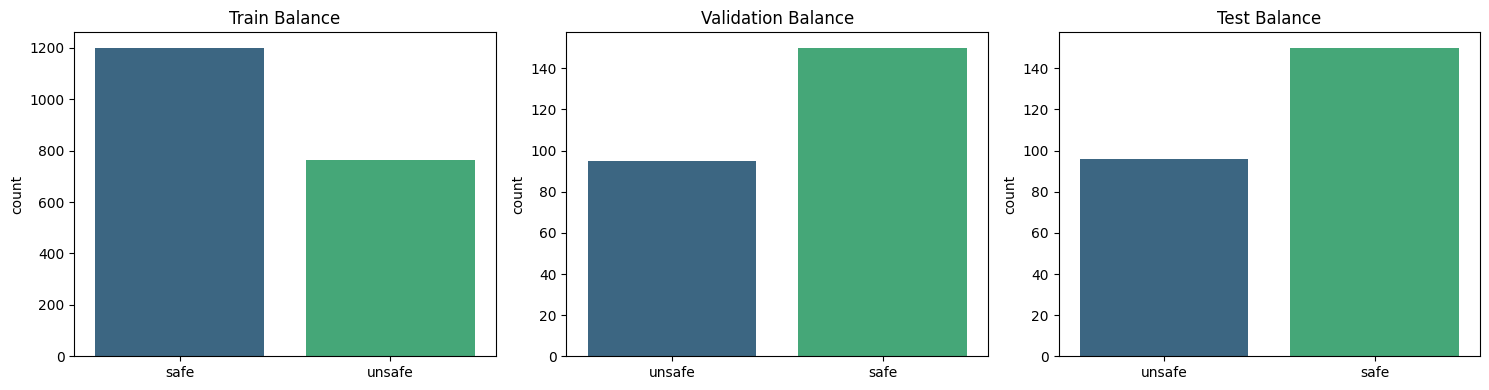

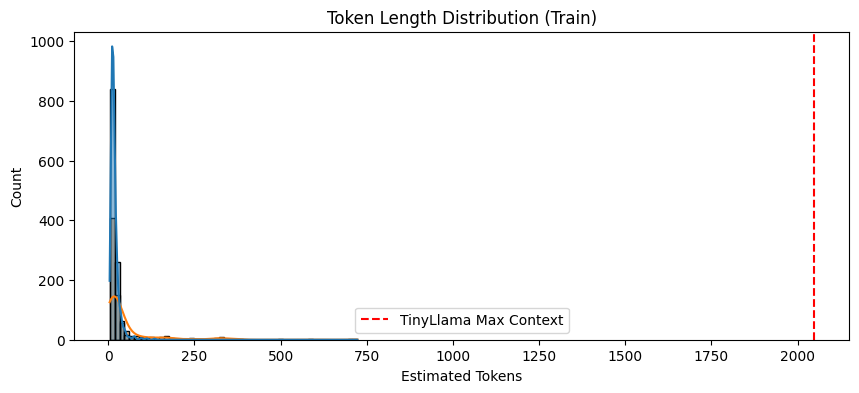


📈 TOKEN STATS:
Max Est. Tokens: 723
Avg Est. Tokens: 30
✅ GREEN LIGHT: All prompts fit comfortably.


In [ ]:
# ==========================================
# 📘 STEP 6: CONSOLIDATE, SPLIT & ANALYZE
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

print("🔄 STARTING FINAL DATASET RE-STRUCTURING...")

# 1. Load the pieces
# Load your new balanced train set
df_balanced = pd.read_csv("/content/drive/MyDrive/BlueTeamLab/data/train_balanced.csv", keep_default_na=False)
# Load the old (imbalanced) val set to recycle its data
df_old_val = pd.read_csv("/content/drive/MyDrive/BlueTeamLab/data/val.csv", keep_default_na=False)

# 2. Merge Everything
full_pool = pd.concat([df_balanced, df_old_val], ignore_index=True)
# Drop duplicates just in case
full_pool = full_pool.drop_duplicates(subset=['text'])
# Shuffle
full_pool = full_pool.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📦 Total Data Pool: {len(full_pool)} examples")

# 3. Create Splits (80% Train, 10% Val, 10% Test)
# First split: Train vs Temp (Val+Test)
train_final, temp_df = train_test_split(full_pool, test_size=0.2, stratify=full_pool['label'], random_state=42)
# Second split: Val vs Test
val_final, test_final = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# 4. Save Final Files
train_final.to_csv("/content/drive/MyDrive/BlueTeamLab/data/train.csv", index=False)
val_final.to_csv("/content/drive/MyDrive/BlueTeamLab/data/val.csv", index=False)
test_final.to_csv("/content/drive/MyDrive/BlueTeamLab/data/test.csv", index=False)

print("\n✅ FILES SAVED:")
print(f"   Train: {len(train_final)} (For Learning)")
print(f"   Val:   {len(val_final)}   (For Checking Progress)")
print(f"   Test:  {len(test_final)}   (For Final Score)")

# ==========================================
# 📊 QUALITY ANALYSIS (ON FINAL DATA)
# ==========================================
print("\n📊 FINAL QUALITY CONTROL")
print("-" * 30)

# A. Verify Balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Train', 'Validation', 'Test']
datasets = [train_final, val_final, test_final]

for i, df in enumerate(datasets):
    sns.countplot(x='label', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f"{titles[i]} Balance")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# B. Verify Token Lengths (To ensure prompts fit in TinyLlama)
# We calculate roughly 1.3 tokens per word
train_final['est_tokens'] = train_final['text'].apply(lambda x: len(str(x).split()) * 1.3)

plt.figure(figsize=(10, 4))
sns.histplot(data=train_final, x='est_tokens', hue='label', bins=50, kde=True)
plt.axvline(x=2048, color='r', linestyle='--', label='TinyLlama Max Context')
plt.title("Token Length Distribution (Train)")
plt.xlabel("Estimated Tokens")
plt.legend()
plt.show()

print("\n📈 TOKEN STATS:")
print(f"Max Est. Tokens: {train_final['est_tokens'].max():.0f}")
print(f"Avg Est. Tokens: {train_final['est_tokens'].mean():.0f}")
if train_final['est_tokens'].max() > 2000:
    print("⚠️ WARNING: Some prompts might be truncated!")
else:
    print("✅ GREEN LIGHT: All prompts fit comfortably.")